<a href="https://colab.research.google.com/github/yohanagabrielasr-prog/HandsOnMg4/blob/main/PROJEK_ANREG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving boston.xlsx to boston.xlsx
INFO DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    int64  
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    int64  
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(10), int64(4)
memory usage: 55.5 KB
None

STATISTIK DESKRIPTIF
               CRIM          ZN         INDUS        CHAS         NOX  \
count  5.060000e+02  506.000000    506.000000  506.000000  506.000000   
mean   3.486526e+0

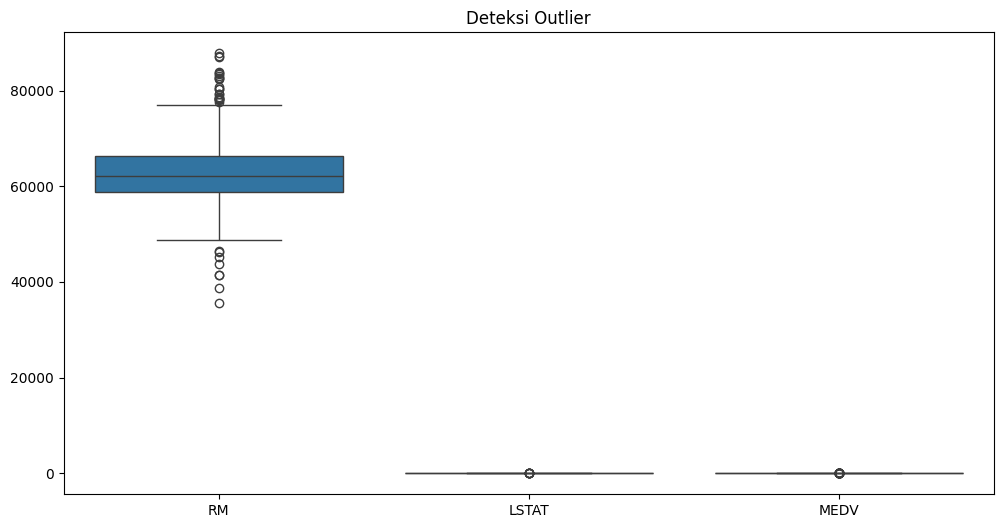

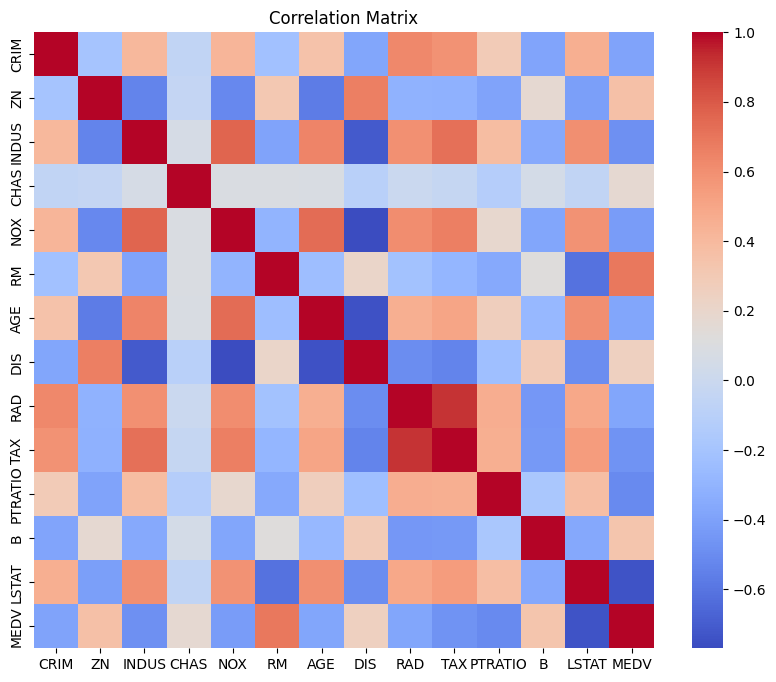


Korelasi RM vs MEDV: 0.6953599470715384

HASIL REGRESI
                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     471.8
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           2.49e-74
Time:                        15:42:56   Log-Likelihood:                -1673.1
No. Observations:                 506   AIC:                             3350.
Df Residuals:                     504   BIC:                             3359.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

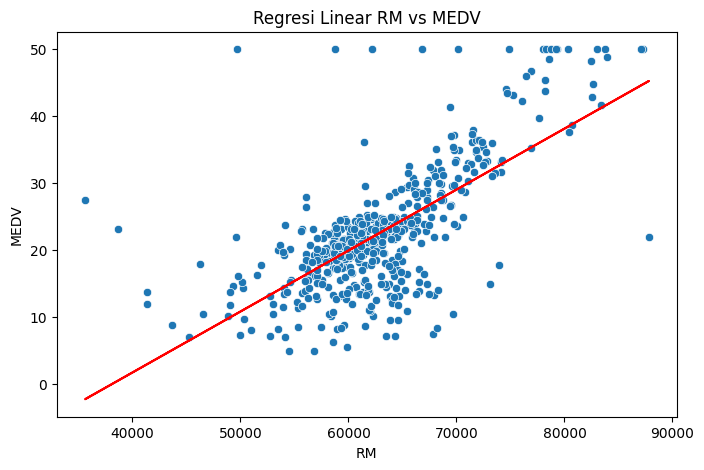

In [ ]:
# ===============================
# UPLOAD FILE (CHOOSE FILE)
# ===============================
from google.colab import files
uploaded = files.upload()

# ===============================
# IMPORT LIBRARY
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from scipy import stats

# ===============================
# LOAD DATA OTOMATIS
# ===============================
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

# Jika nama kolom kecil
df.columns = df.columns.str.upper()

# ===============================
# 1. INFO DATA
# ===============================
print("INFO DATA")
print(df.info())

print("\nSTATISTIK DESKRIPTIF")
print(df.describe())

# ===============================
# 2. MISSING VALUES
# ===============================
print("\nMISSING VALUES")
print(df.isnull().sum())

# ===============================
# 3. DETEKSI OUTLIER
# ===============================
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['RM','LSTAT','MEDV']])
plt.title("Deteksi Outlier")
plt.show()

# ===============================
# 4. KORELASI
# ===============================
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

print("\nKorelasi RM vs MEDV:", corr.loc['RM','MEDV'])

# ===============================
# 5. REGRESI LINEAR
# ===============================
X = df[['RM']]
y = df['MEDV']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print("\nHASIL REGRESI")
print(model.summary())

# ===============================
# 6. UJI ASUMSI
# ===============================
residuals = model.resid

# Normalitas
stat, p_normal = stats.shapiro(residuals)
print("\nUJI NORMALITAS")
print("p-value:", p_normal)

# Homoskedastisitas
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(residuals, X)
print("\nUJI HOMOSKEDASTISITAS")
print("p-value:", bp_test[1])

# Durbin Watson
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print("\nDURBIN WATSON:", dw)

# ===============================
# 7. VISUALISASI REGRESI
# ===============================
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['RM'], y=df['MEDV'])
plt.plot(df['RM'], model.predict(X), color='red')
plt.title("Regresi Linear RM vs MEDV")
plt.show()